# 04. Segunda pregunta: ¿qué determina el rendimiento?

Se examinan aquí los factores que influyen en la marca de una atleta: peso corporal,
edad, reparto entre movimientos, material y experiencia.

Este cuaderno contiene además el resultado metodológicamente más relevante de todo
el proyecto, en el apartado del equipamiento: un caso en el que controlar un sesgo
invierte por completo la conclusión.

In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

import pandas as pd
import numpy as np
from IPython.display import Image, display

import config as cfg
import estilo
import analisis

estilo.aplicar()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

df = analisis.cargar()


CARGA DEL CONJUNTO FINAL


  825,296 filas x 83 columnas   (dataset_final_powerlifting_femenino.csv)


## Cómo escala la fuerza con el peso corporal

La relación entre peso corporal y fuerza no es lineal, y la forma adecuada de
modelarla es una ley alométrica de la forma `Total = a · Peso^b`. Tomando logaritmos
en ambos lados, el exponente `b` se convierte en la pendiente de una regresión
lineal, lo que permite estimarlo directamente.

Lo relevante es cómo se interpreta ese exponente. Si valiera 1, la fuerza crecería
en la misma proporción que el peso. Si es menor que 1, existen retornos
decrecientes: pesar más da fuerza, pero cada kilo adicional aporta menos que el
anterior.

In [2]:
analisis.a5_peso_fuerza(df)


A5. COMO ESCALA LA FUERZA CON EL PESO CORPORAL
  Modelo alometrico  Total = a * Peso^b
    exponente b = 0.4853  (IC95%: 0.4831 a 0.4875)
    R2 = 0.1835   p = 0.00e+00
    Interpretacion: al duplicar el peso corporal, el total se multiplica por 1.40

  POR CATEGORIA DE PESO:
                     n  total_mediano  fuerza_rel_mediana
categoria_peso                                           
+84 kg          136526         340.19               3.426
-47 kg           43590         219.99               4.936
47-52 kg         80255         251.74               5.035
52-57 kg        106140         272.16               4.935
57-63 kg        131842         285.76               4.770
63-69 kg        124599         303.91               4.591
69-76 kg        116965         319.78               4.397
76-84 kg         85379         326.59               4.065

  Mayor fuerza relativa: categoria 47-52 kg (5.035 x peso corporal)


  [figura] a5_peso_fuerza.png


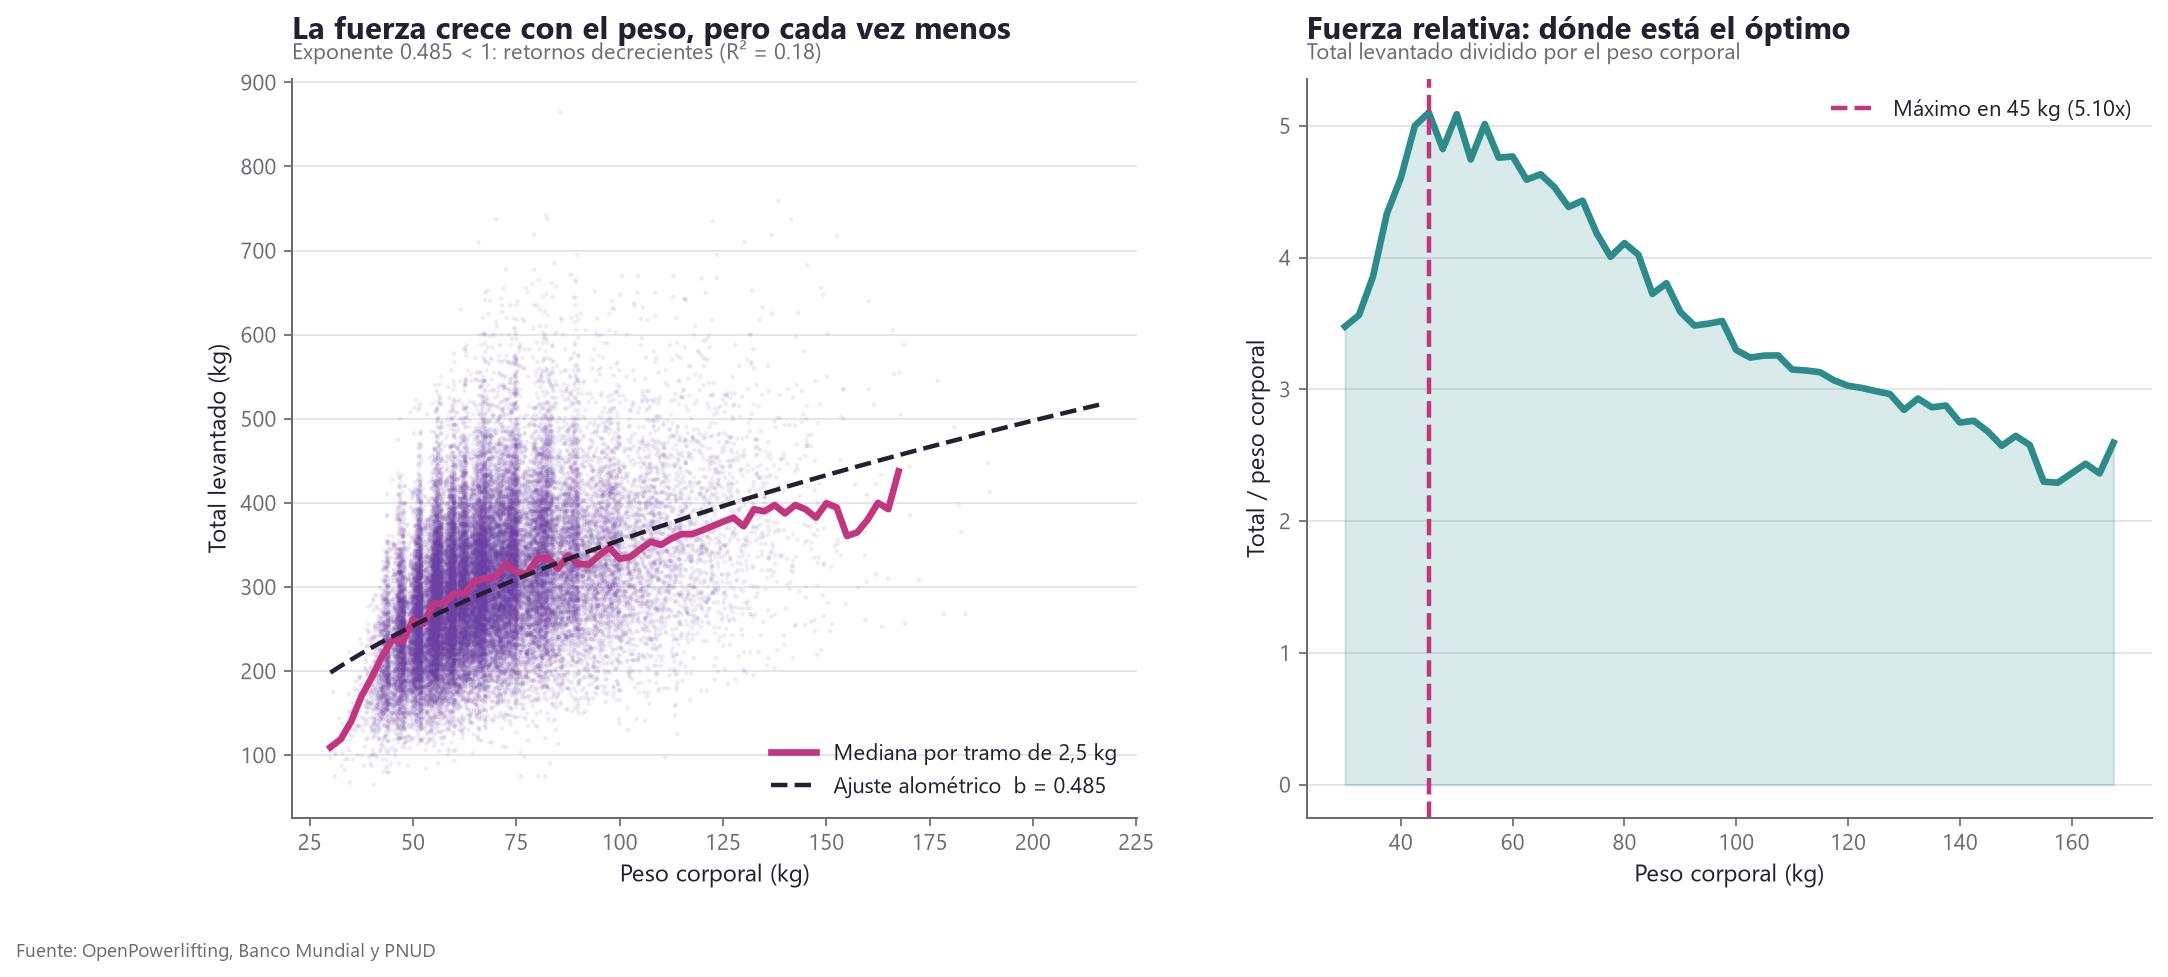

In [3]:
display(Image(filename=str(cfg.FIGURES / "a5_peso_fuerza.png")))

El exponente obtenido es 0,485, claramente por debajo de 1. Duplicar el peso
corporal no duplica la fuerza: la multiplica por 1,4.

El R² del ajuste es de 0,18, y conviene leerlo con cuidado. El peso corporal
explica solo el 18% de la variabilidad del total, porque entre dos atletas que
pesan lo mismo las marcas difieren mucho. Lo que el ajuste estima con precisión,
gracias a las 825.296 observaciones, es la forma de la relación media.

Este resultado tiene una explicación fisiológica conocida. La fuerza depende de la
sección transversal del músculo, que escala en dos dimensiones, mientras que la masa
corporal escala en tres. Que el dato empírico coincida con lo que predice la teoría
refuerza la confianza en la calidad de los datos.

De aquí se deriva una consecuencia práctica: las categorías de peso ligeras son las
más eficientes en fuerza relativa. Y es exactamente por esto que existen índices
como DOTS o Wilks, porque sin ellos comparar atletas de distinto peso premiaría
siempre a las más pesadas.

## Edad y pico de rendimiento

In [4]:
analisis.a6_edad(df)


A6. EDAD Y PICO DE RENDIMIENTO


  Registros con edad conocida: 474,759 (57.5%)
  Pico de rendimiento (DOTS mediano): 24 anios (353.6 puntos)
  Meseta de alto rendimiento (>=98% del maximo): 22-28 anios

  POR GRUPO DE EDAD:
                     n  dots_mediano  total_mediano  pct_podio
grupo_edad                                                    
18-23 (junior)  104533        342.68         320.00       76.3
24-30           111848        349.37         335.00       78.5
31-40            92609        340.18         335.00       82.1
41-50 (master)   55605        326.01         322.05       88.2
51-60 (master)   24153        298.61         292.50       89.3
60+ (master)     10747        254.63         242.50       92.4
Sub-18           75261        299.16         275.00       75.3



  Kruskal-Wallis entre grupos de edad: H=37636.0  p=0.000e+00
  [figura] a6_edad_rendimiento.png


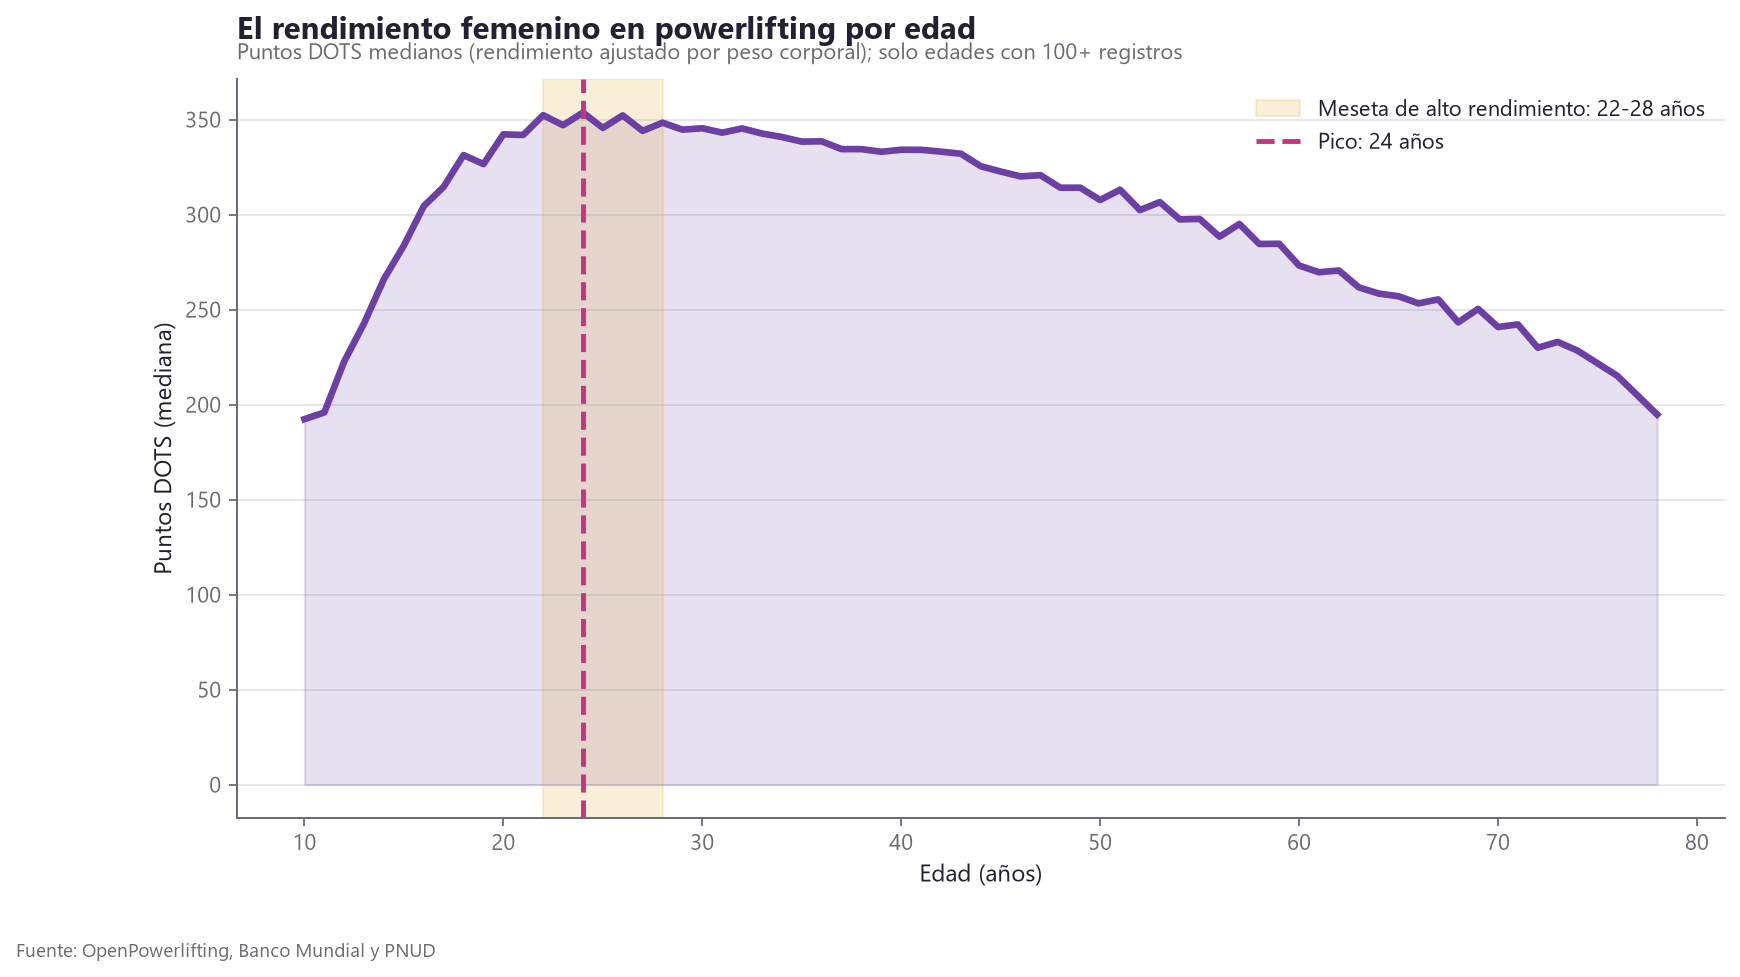

In [5]:
display(Image(filename=str(cfg.FIGURES / "a6_edad_rendimiento.png")))

El pico se sitúa en torno a los 24 años, con una meseta de alto rendimiento entre
los 22 y los 28. A partir de ahí el descenso es gradual y no abrupto.

Hay en la tabla anterior un detalle que conviene explicar, porque a primera vista
parece contradictorio: el porcentaje de podios aumenta con la edad, justo cuando el
rendimiento baja. La explicación es que en las categorías de veteranas hay muchas
menos participantes, de modo que la probabilidad de acabar entre las tres primeras
es mecánicamente mayor. El podio mide competencia relativa, no nivel absoluto.

Conviene recordar que la edad falta en el 42% de los registros, así que este
análisis usa el subconjunto con dato. No hay motivo para pensar que la ausencia esté
relacionada con la edad real, pero es una limitación que debe constar.

## El reparto entre los tres movimientos

In [6]:
analisis.a7_arquetipos(df)


A7. REPARTO DEL TOTAL ENTRE LOS TRES MOVIMIENTOS


  Contribucion de cada movimiento al total (%):
                  mean   std    25%    50%    75%
pct_sentadilla   37.36  3.49  35.29  37.50  39.64
pct_banca        20.29  2.78  18.45  20.12  21.91
pct_peso_muerto  42.35  3.83  40.00  42.36  44.78

  ARQUETIPOS DE FUERZA:
                               n  total_mediano  dots_mediano  fuerza_rel  pct_podio  pct_del_total
perfil_fuerza                                                                                      
Dominante en banca        239325         315.25        327.79       4.653       72.5           29.0
Dominante en peso muerto  297977         275.00        293.02       4.258       71.9           36.1
Dominante en sentadilla   287994         307.50        317.88       4.479       64.1           34.9

  Chi-cuadrado perfil vs podio: chi2=5775.2  gl=2  p=0.000e+00
  V de Cramer = 0.0837  (asociacion practicamente nula)


  [figura] a7_arquetipos_fuerza.png


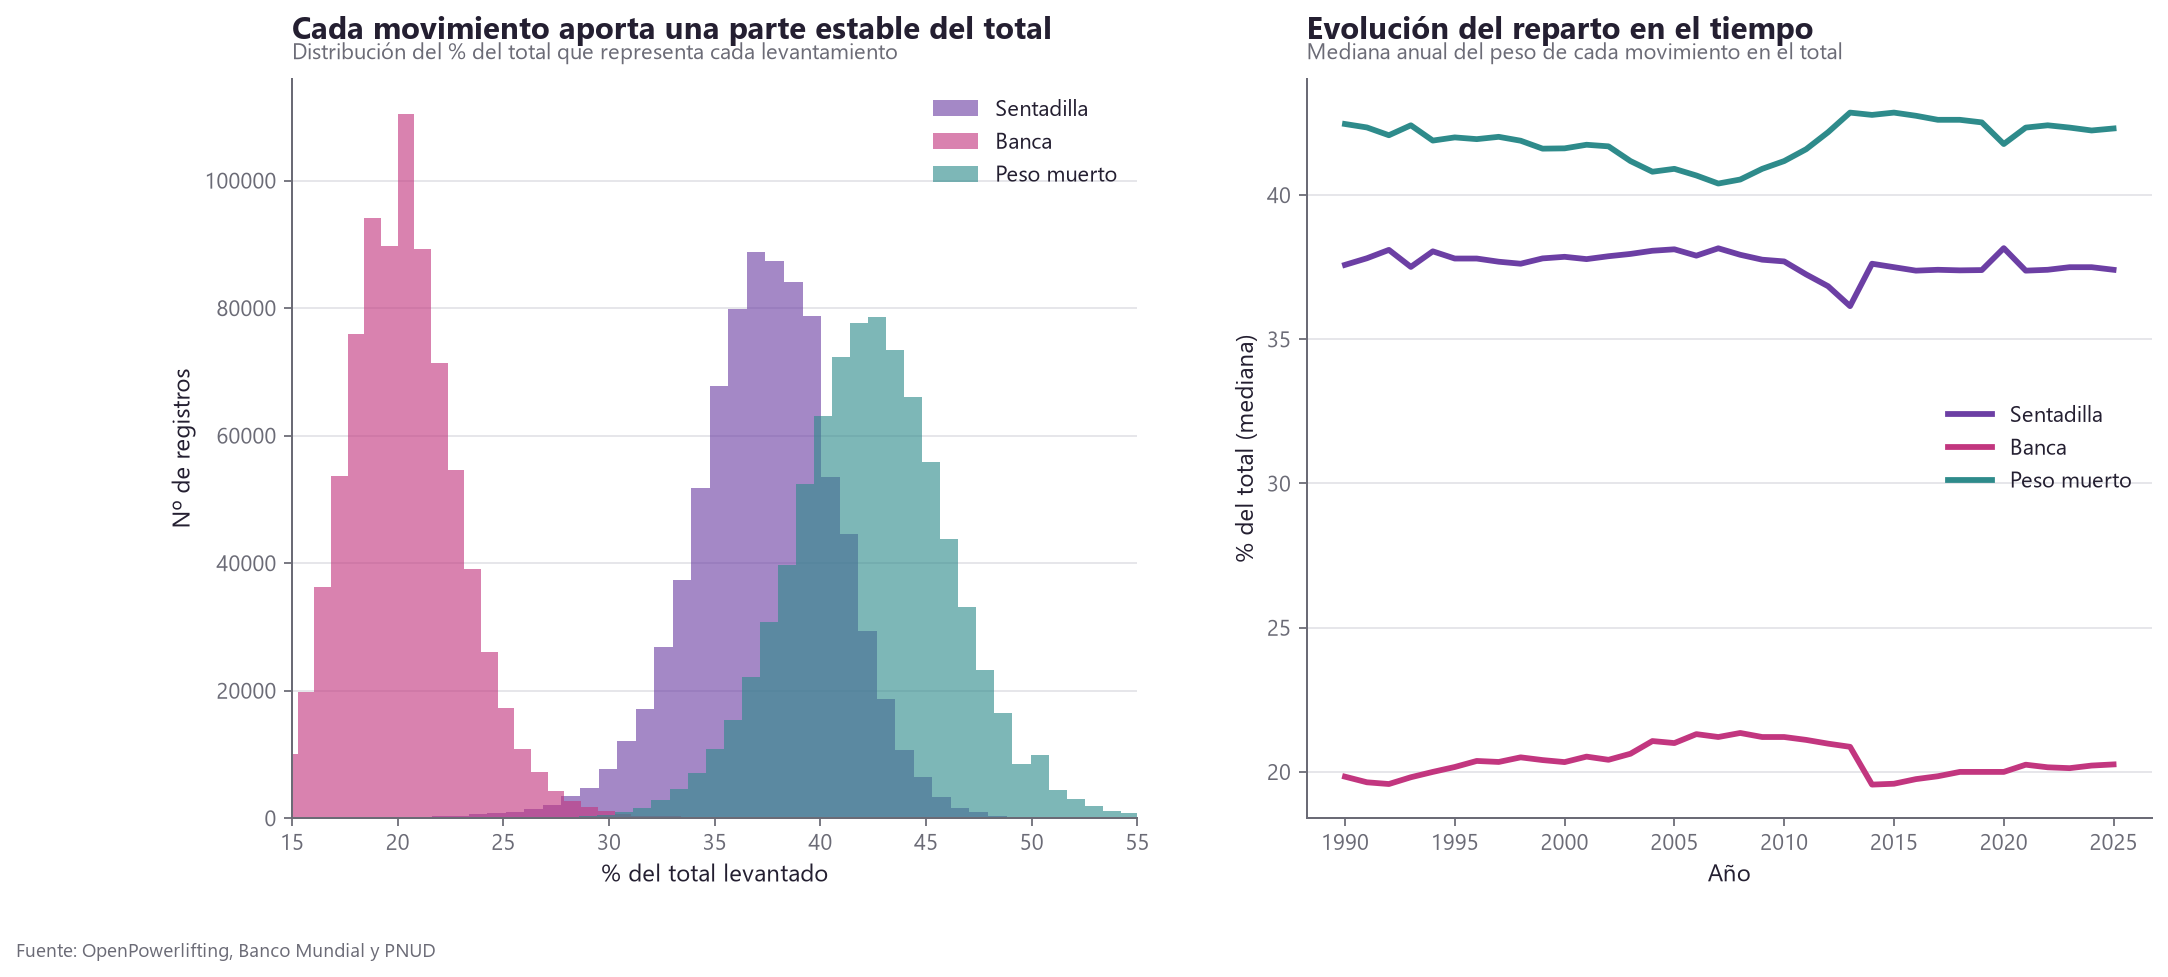

In [7]:
display(Image(filename=str(cfg.FIGURES / "a7_arquetipos_fuerza.png")))

El reparto del total resulta notablemente estable: el peso muerto aporta en torno al
42%, la sentadilla el 37% y el press de banca el 20%. Las desviaciones típicas son
de solo tres o cuatro puntos, lo que apunta a una estructura biomecánica bastante
universal.

Sobre los arquetipos de fuerza, la prueba chi-cuadrado sale significativa, como
ocurre con casi todo cuando se trabaja con 825.000 filas, pero la V de Cramer es de
apenas 0,08, es decir, una asociación prácticamente nula. La conclusión honesta es
que el perfil de fuerza no determina el éxito competitivo.

Este caso ilustra por qué en muestras grandes hay que mirar siempre el tamaño del
efecto y no solo el p-valor: un p-valor de 0,000 acompañado de una V de Cramer de
0,08 significa que el efecto existe pero es irrelevante.

## El equipamiento: cuando controlar un sesgo invierte la conclusión

In [8]:
analisis.a8_equipamiento(df)


A8. EFECTO DEL EQUIPAMIENTO
                   n  total_mediano  dots_mediano  fuerza_rel  peso_mediano
equipamiento                                                               
Multi-ply       7230         392.36        407.80        5.83         67.00
Wraps          58174         317.50        325.13        4.58         67.30
Raw           373115         306.17        317.83        4.51         66.84
Single-ply    247656         288.03        309.95        4.50         62.40
Unlimited     139121         272.16        287.27        4.08         65.77



  Con equipamiento: mediana 301.7 DOTS (n=394,007)
  Sin equipamiento: mediana 318.8 DOTS (n=431,289)
  Ventaja del equipamiento: -5.4%
  t de Welch = -53.0 (p=0.00e+00)   Mann-Whitney p=0.00e+00
  d de Cohen = -0.118 (tamano del efecto)

  --------------------------------------------------------------------
  CONTROL DEL SESGO: el equipamiento va ligado a la federacion
  --------------------------------------------------------------------



  (a) Comparacion pareada intra-atleta: 14,051 atletas han competido en
      ambas modalidades
      Fuerza relativa mediana con equipamiento : 4.659
      Fuerza relativa mediana sin equipamiento : 4.293
      Diferencia mediana intra-atleta: +0.392 (+9.1%)
      Wilcoxon pareado: W=24879626  p=0.000e+00
      -> el equipamiento SI aporta ventaja cuando se compara a la misma atleta

  (b) Dentro del mismo ambito federativo:


      Federacion independiente         equipada 4.088 | sin equipar 4.276 | -4.4%  p=0.00e+00


      Internacional (IPF)              equipada 5.337 | sin equipar 4.659 | +14.6%  p=0.00e+00
      Otra federacion internacional    equipada 5.548 | sin equipar 4.502 | +23.2%  p=0.00e+00


  [figura] a8_equipamiento.png


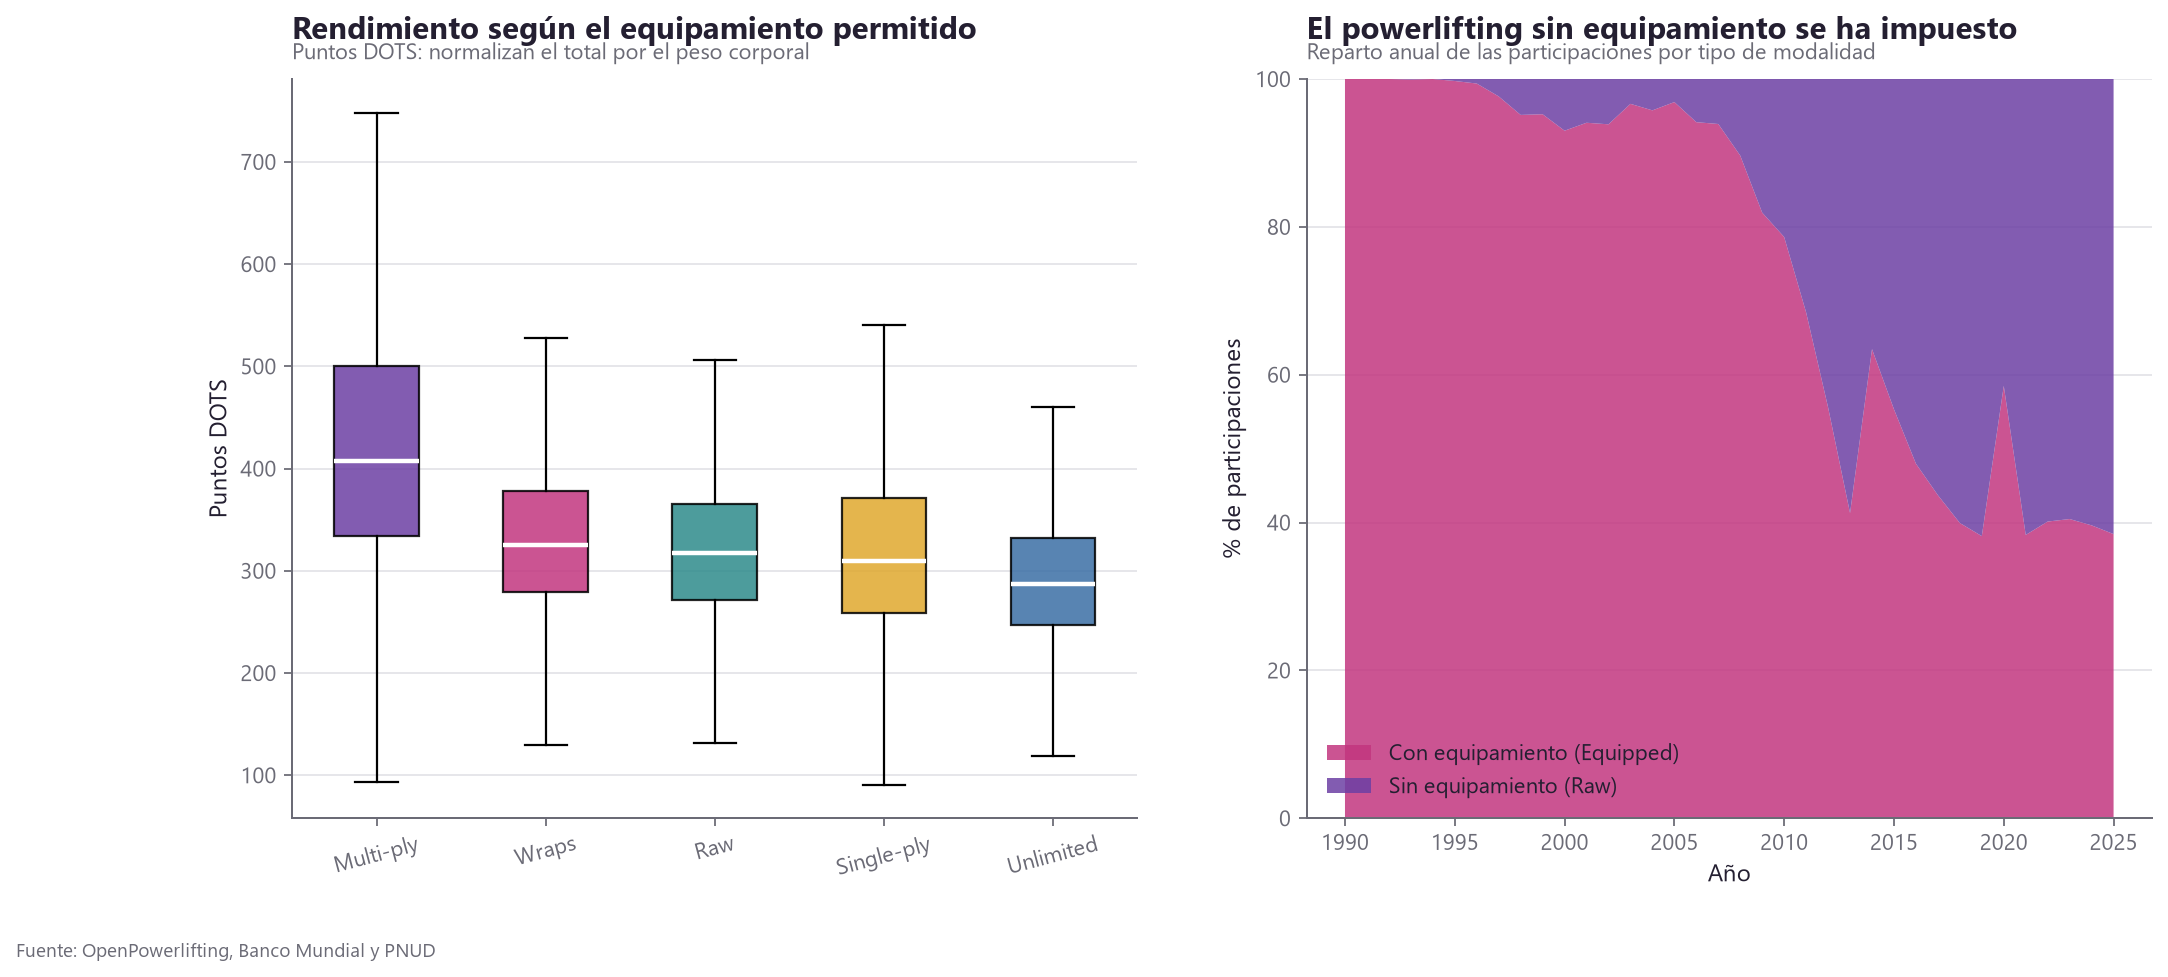

In [9]:
display(Image(filename=str(cfg.FIGURES / "a8_equipamiento.png")))

La comparación directa entre modalidades daba un resultado que no se sostiene: el
equipamiento parecía empeorar el rendimiento en un 5,3%. Es físicamente imposible,
porque el material elástico acumula energía y ayuda a levantar más.

La causa es un sesgo de composición. El tipo de equipamiento no se asigna al azar,
sino que va ligado a la federación, y las federaciones difieren enormemente en nivel
competitivo. La modalidad `Unlimited` aparece sobre todo en circuitos amateur, lo
que arrastra su media hacia abajo y contamina la comparación.

La solución adoptada fue una comparación pareada intra-atleta: tomar solo a las
14.051 atletas que han competido en ambas modalidades y comparar cada una consigo
misma, lo que elimina de raíz las diferencias de nivel entre personas.

| Método | Resultado | ¿Creíble? |
|---|---|---|
| Comparación directa entre grupos | −5,3% | No, contradice la física |
| Comparación pareada intra-atleta | +9,1% (Wilcoxon, p≈0) | Sí |

El signo se invierte. Es un caso de manual de por qué en datos observacionales la
comparación bruta entre grupos puede engañar, y de por qué conviene buscar un diseño
que controle las diferencias de partida.

## Trayectoria y progresión

In [10]:
analisis.a9_trayectoria(df)


A9. TRAYECTORIA Y PROGRESION DE LAS ATLETAS
  Competiciones por atleta: mediana 2, media 3.63, maximo 177
  Atletas con una sola competicion: 40.3%  (abandono temprano)
  Atletas con 10 o mas competiciones: 8.1%



  PROGRESION POR NUMERO DE COMPETICION:
                    n    dots   total  mejora  pct_record
n_competicion                                            
1              227570  277.14  262.50     NaN         0.0
2              135779  294.89  280.00    15.9        78.1
3               94951  307.14  292.57    11.3        71.3
4               70430  317.02  303.91     8.5        62.3
5               53654  325.58  312.50     7.5        57.1
6               42047  331.57  317.51     6.8        53.2
7               33673  338.04  325.00     6.8        51.1
8               27587  343.14  331.12     5.0        47.4
9               22481  348.39  335.66     5.0        45.3
10              18492  353.50  340.00     4.5        42.6
11              15272  358.41  345.00     4.5        40.5
12              12723  362.81  349.27     4.5        38.4

  Mejora entre competiciones consecutivas: mediana +9.1 kg


  Registros que son record personal: 42.4%


  Correlacion (Spearman) nº competicion vs mejora: rho=-0.2329  p=0.00e+00


  [figura] a9_trayectoria.png


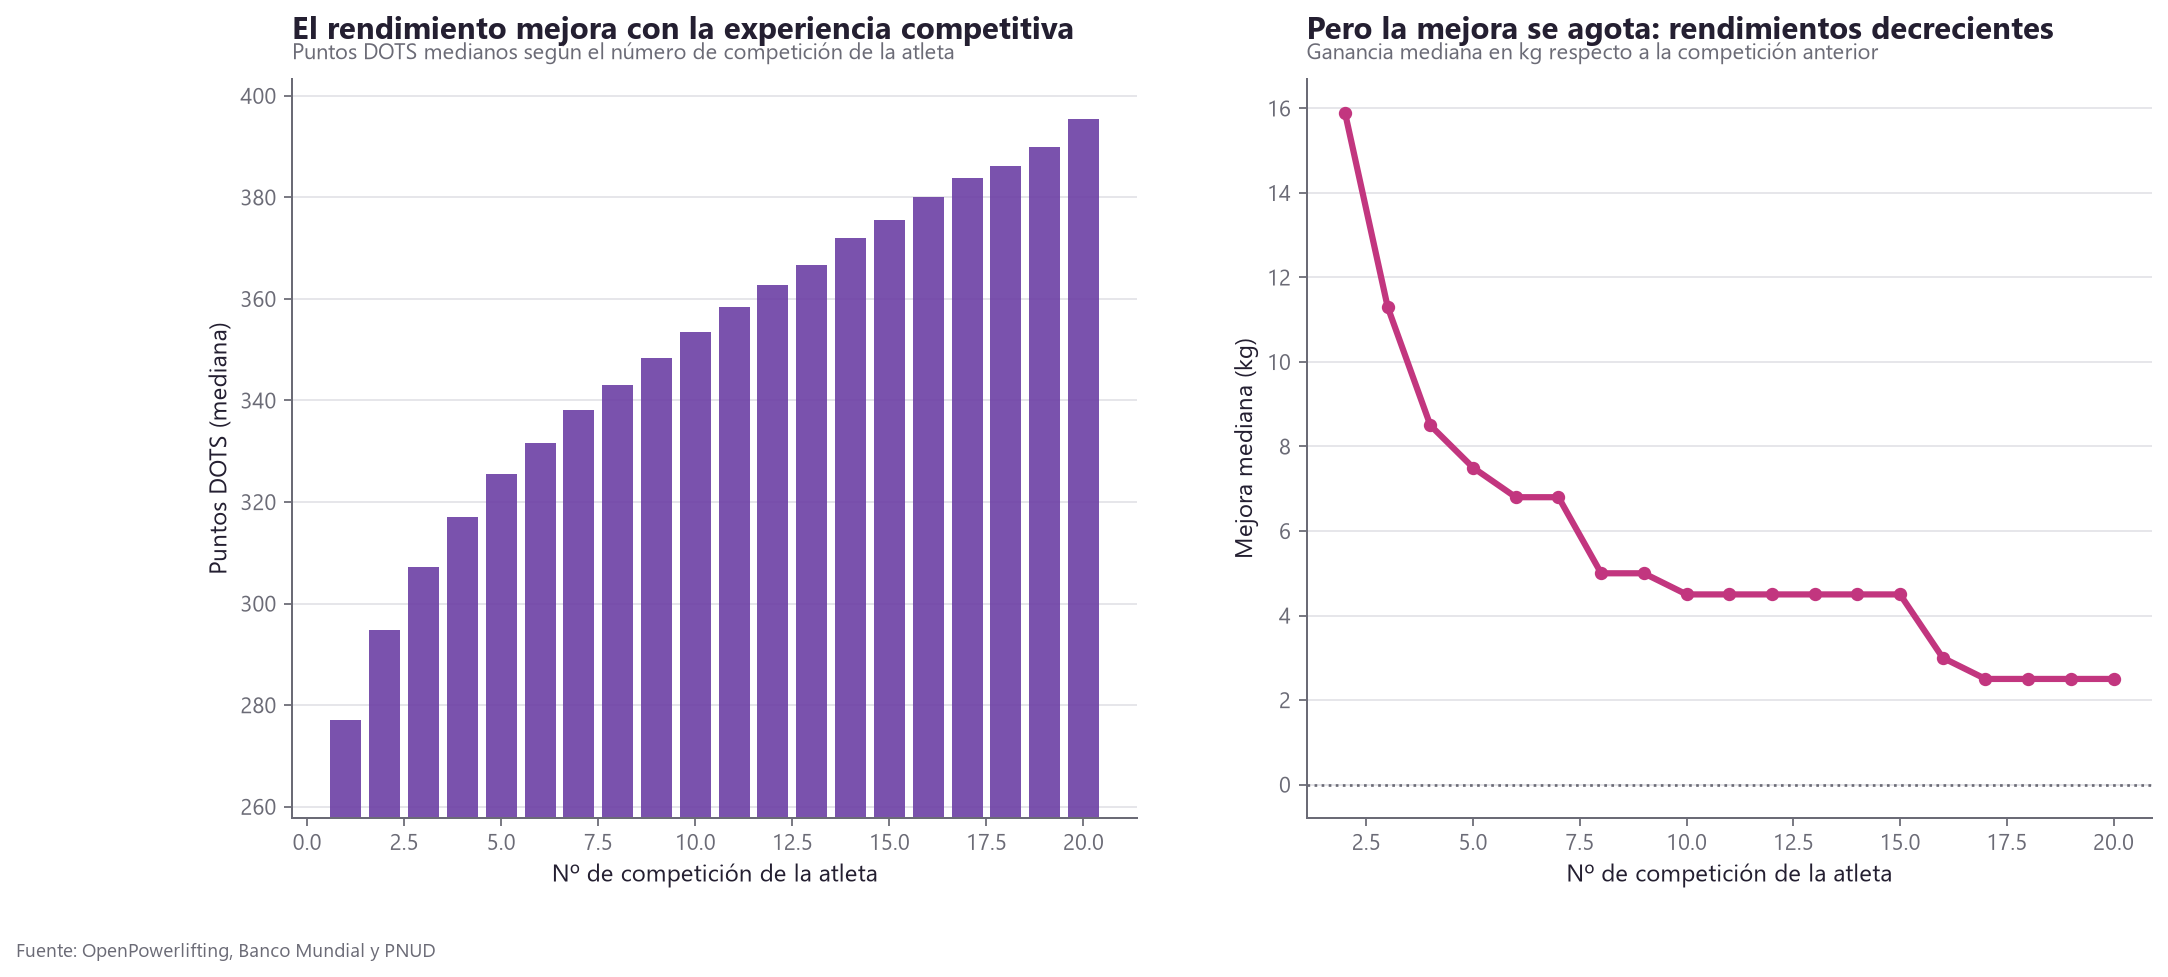

In [11]:
display(Image(filename=str(cfg.FIGURES / "a9_trayectoria.png")))

Se observan dos patrones claros.

El rendimiento mejora con la experiencia de forma sostenida: cada competición
adicional se asocia a una marca mejor. Pero la mejora se agota, pasando de 15,9 kg
entre la primera y la segunda competición a solo 4,5 kg hacia la décima. La
correlación negativa entre número de competición y ganancia, con un rho de −0,23,
confirma los rendimientos decrecientes.

Hay además un dato con lectura directa para una federación: el 40% de las atletas
compite una sola vez. El problema del deporte es la retención, no la captación.

Una advertencia sobre la causalidad: parte de la mejora aparente es sesgo de
supervivencia. Quienes siguen compitiendo hasta la décima vez son, en promedio, las
que mejor resultado obtuvieron antes, así que no todo el efecto es entrenamiento.

## Contexto: la brecha respecto a los hombres

In [12]:
analisis.a10_brecha(df)


A10. BRECHA DE RENDIMIENTO RESPECTO A LOS HOMBRES
  Metrica utilizada: FUERZA RELATIVA (total / peso corporal).
  DOTS y Wilks quedan descartados para comparar sexos porque ya
  estan normalizados POR sexo (se muestran solo para ilustrarlo).



  FUERZA RELATIVA mujeres/hombres:
    1990: 77.2%   2025: 73.3%
    Tendencia: -0.1740 p.p./anio (R2=0.222, p=3.77e-03)
  TOTAL ABSOLUTO mujeres/hombres:
    1990: 55.3%   2025: 57.8%
  DOTS (NO valido entre sexos, solo ilustrativo):
    1990: 91.9%   2025: 89.5%   <- por encima de 100% precisamente porque el indice ya ajusta por sexo

  CONCLUSION: la brecha de fuerza relativa se amplia


  [figura] a10_brecha_genero.png


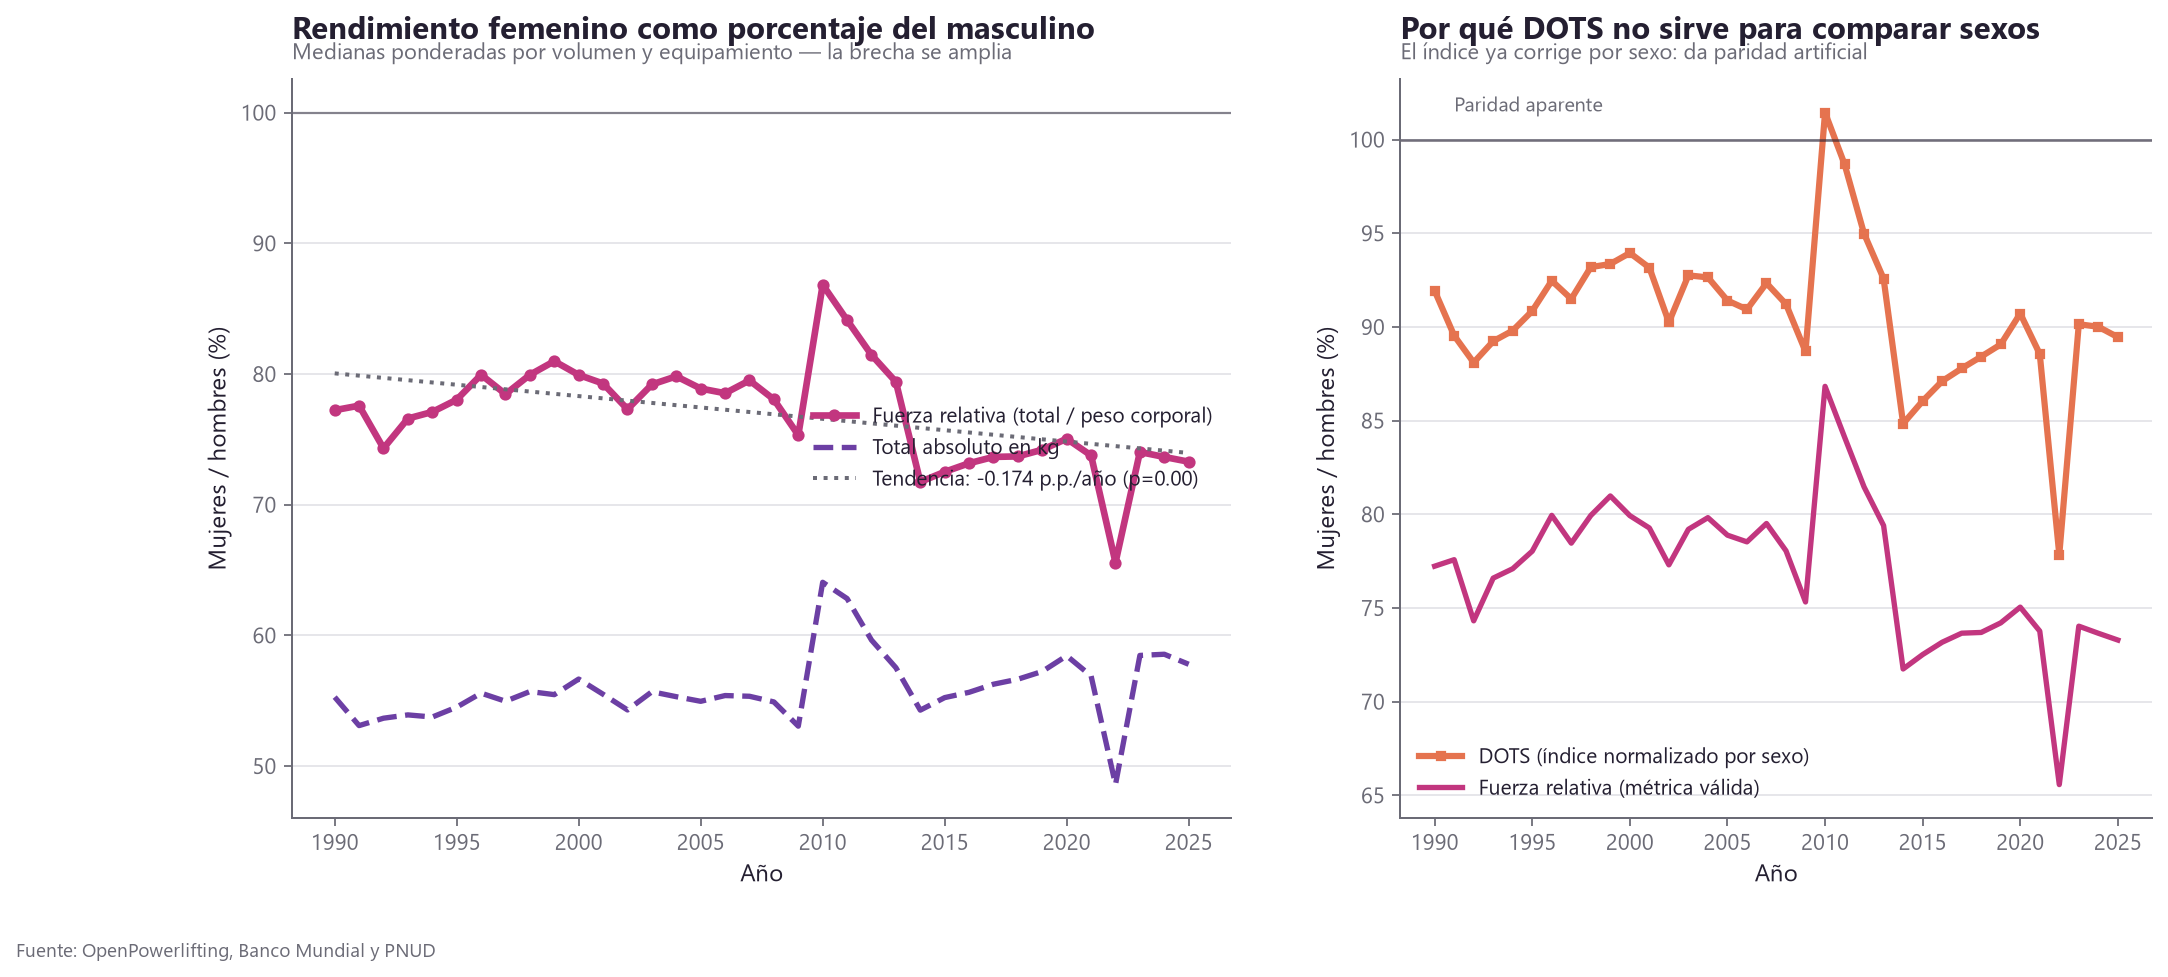

In [13]:
display(Image(filename=str(cfg.FIGURES / "a10_brecha_genero.png")))

La elección de la métrica resulta determinante en este apartado.

DOTS y Wilks no sirven para comparar sexos, porque aplican coeficientes distintos a
hombres y a mujeres precisamente para permitir comparaciones dentro de cada sexo.
Usarlos entre sexos produce el resultado sin sentido que muestra el panel derecho:
un ratio superior al 100%, es decir, que las mujeres levantan más que los hombres.

La métrica válida es la fuerza relativa, el total dividido por el peso corporal, que
no incorpora ningún ajuste por sexo. Con ella, las mujeres se sitúan en torno al 73
o 77% del rendimiento masculino, una cifra coherente con la literatura fisiológica
sobre diferencias de fuerza.

La brecha no se estrecha, sino que se amplía muy ligeramente. Una hipótesis
plausible es que, al masificarse la participación femenina, entra mucha más gente
principiante y eso baja la mediana: no sería que las mujeres de élite retrocedan,
sino que la base se ensancha.

## Control antidopaje

In [14]:
analisis.a11_antidopaje(df)


A11. DECLARACION DE CONTROL ANTIDOPAJE Y RENDIMIENTO
  Lectura correcta del dato: se compara si la federacion DECLARA
  programa antidopaje, no si hubo o no control efectivo.

                           n  dots_mediano  total_mediano  fuerza_rel
control_antidoping                                                   
Control declarado     709981        308.69         294.84       4.410
Control no declarado  115315        325.48         315.00       4.626

  Comparacion dentro de cada modalidad (control del sesgo):


    Sin equipamiento (Raw)       declarado 4.507 | no declarado 4.549 | dif +0.9% | p=8.67e-50  (n=336,996 / 94,293)


    Con equipamiento (Equipped)  declarado 4.310 | no declarado 5.023 | dif +16.5% | p=0.00e+00  (n=372,985 / 21,022)


El campo original solo toma el valor `Yes` o queda vacío, así que no existe un "no
hubo control" explícito. Lo único que puede compararse es si la federación declara
programa antidopaje o no, y las etiquetas del conjunto final lo reflejan así
(`Control declarado` y `Control no declarado`) para no inducir a una lectura
equivocada.

## Matriz de correlaciones

In [15]:
analisis.a12_correlaciones(df)


A12. MATRIZ DE CORRELACIONES ENTRE VARIABLES CLAVE


                            total_kg  fuerza_relativa  puntos_dots  peso_corporal_kg   edad  n_competicion  tasa_acierto_intentos  pct_participacion_femenina  indice_desigualdad_gen    idh  pib_per_capita_ppa  tasa_actividad_femenina
total_kg                       1.000            0.590        0.857             0.426  0.104          0.396                  0.066                      -0.027                  -0.122  0.050              -0.075                    0.042
fuerza_relativa                0.590            1.000        0.912            -0.416 -0.041          0.354                 -0.022                      -0.163                  -0.048 -0.091              -0.202                   -0.060
puntos_dots                    0.857            0.912        1.000            -0.059  0.021          0.420                  0.017                      -0.112                  -0.087 -0.034              -0.161                   -0.017
peso_corporal_kg               0.426           -0.416       -0.0


  [figura] a12_matriz_correlaciones.png


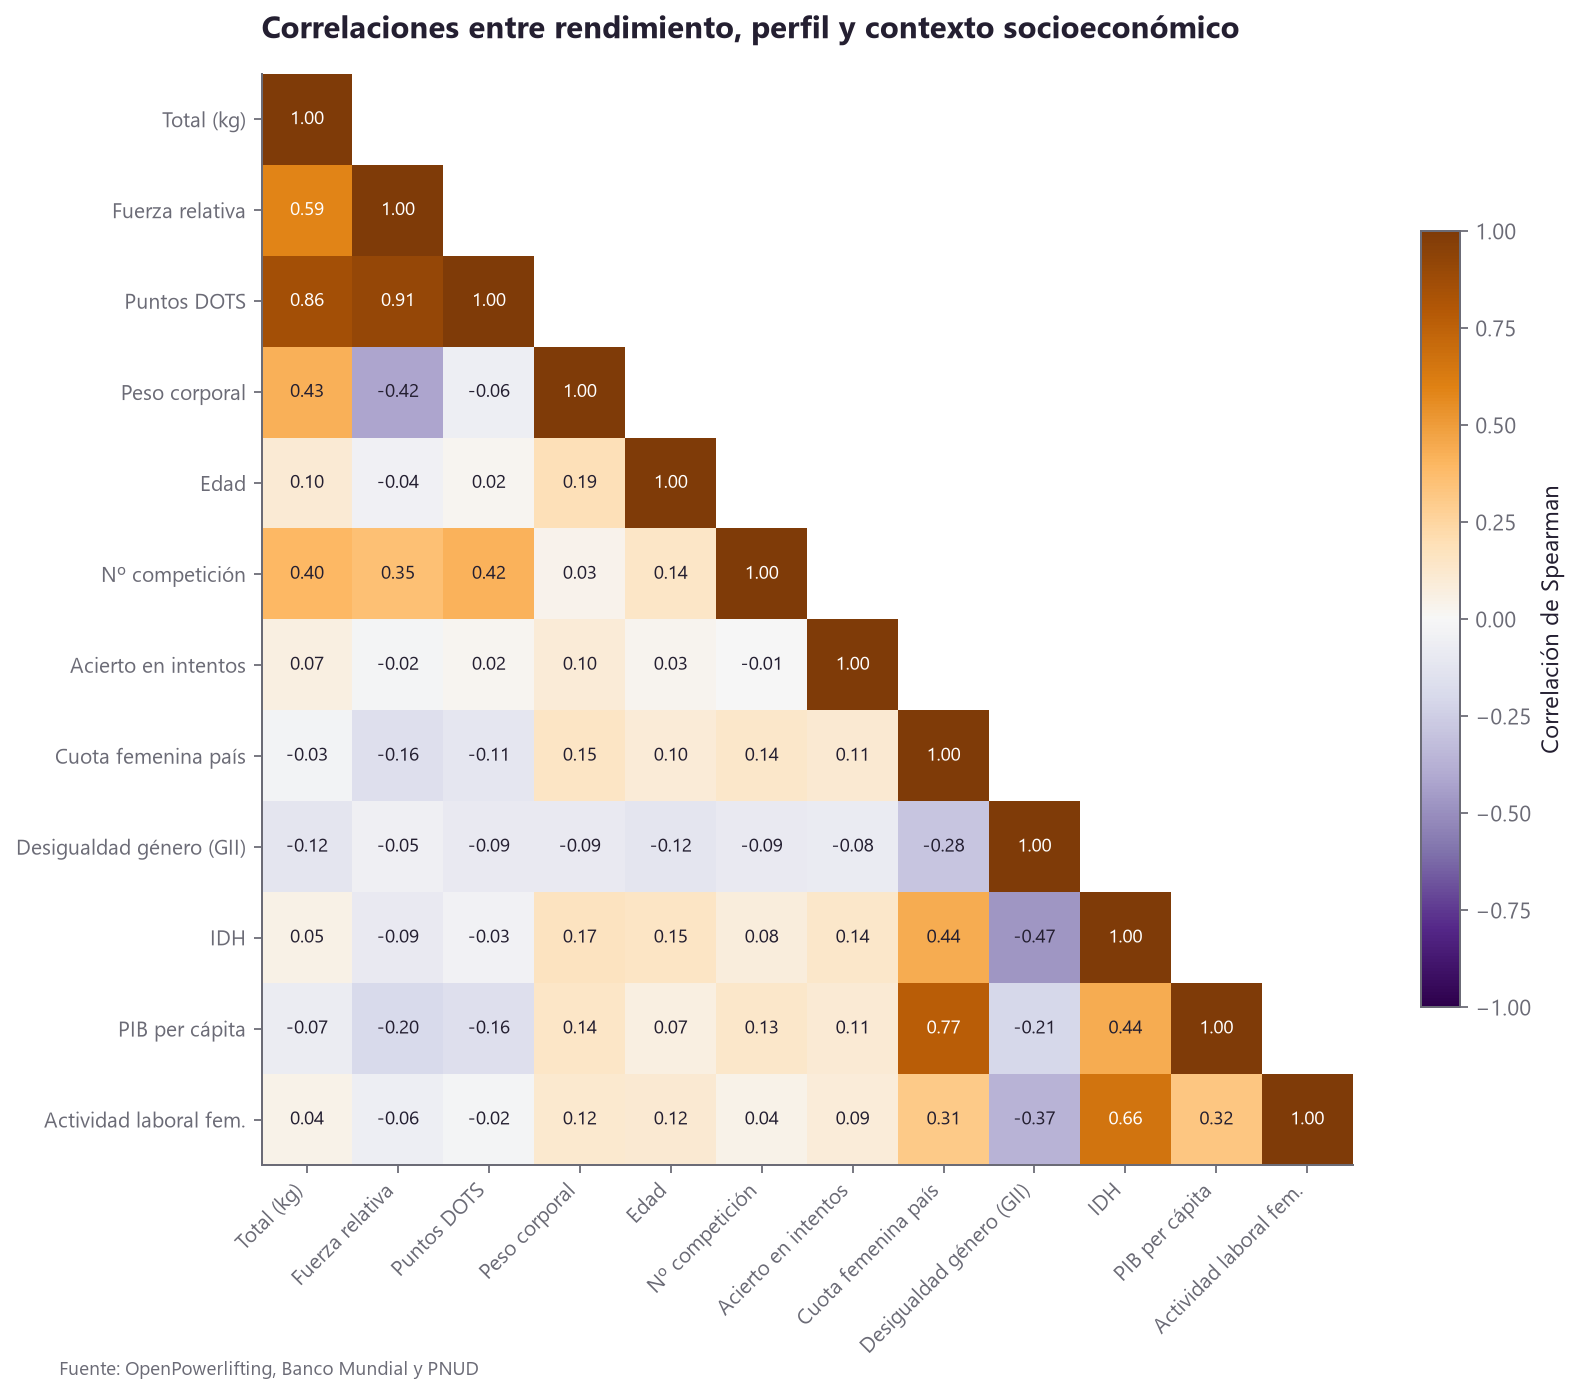

In [16]:
display(Image(filename=str(cfg.FIGURES / "a12_matriz_correlaciones.png")))

La matriz confirma la coherencia interna del conjunto y aporta un detalle revelador:
la cuota de participación femenina del país correlaciona con el PIB per cápita, con
un rho de 0,77, mucho más que con el índice de desigualdad de género, cuyo rho es de
−0,28.

Es la primera pista de lo que se explora a fondo en el siguiente cuaderno.

## Síntesis de la segunda pregunta

El peso corporal es determinante, con retornos decrecientes y un exponente
alométrico de 0,485 que tiene base fisiológica sólida.

La edad marca un pico a los 24 años y una meseta entre los 22 y los 28, aunque el
dato falta en el 42% de los registros.

El reparto entre movimientos es muy estable (42, 37 y 20 por ciento), y el perfil
dominante no predice el éxito, con una V de Cramer de apenas 0,08.

El equipamiento aporta un 9,1% medido intra-atleta, frente al −5,3% que daba la
comparación bruta.

La experiencia mejora el rendimiento, pero de forma decreciente y con sesgo de
supervivencia.

El siguiente cuaderno, `05_pregunta3_contexto_social.ipynb`, aborda el papel del
contexto del país.